<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°1 de TPS

En esta sección se importan las bibliotecas permitidas se utilizarán a lo largo del trabajo práctico.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Item A



### Punto 1

Se carga la base de datos usados en este trabajo práctico.

In [20]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

Se verifica que los mismos se hayan cargado correctamente:

In [21]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


### Punto 2


Se procede a gráficar los datos para poder analizarlos mejor.

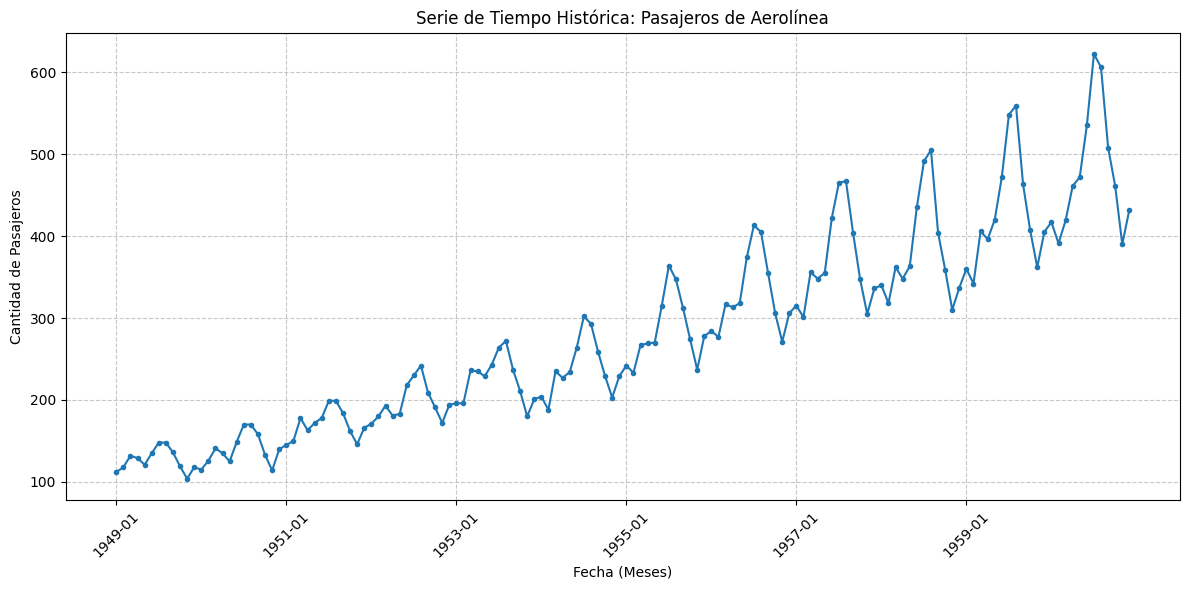

In [22]:
# Definir el tamaño del área de visualización
plt.figure(figsize=(12, 6))

# Trazar la serie de pasajeros a lo largo del tiempo
# El eje X corresponde a los meses y el eje Y a la cantidad de pasajeros
plt.plot(df['Month'], df['Passengers'], color='tab:blue', marker='.', linestyle='-')

# Añadir etiquetas descriptivas a los ejes y título del gráfico
plt.xlabel('Fecha (Meses)')
plt.ylabel('Cantidad de Pasajeros')
plt.title('Serie de Tiempo Histórica: Pasajeros de Aerolínea')

# Mostrar marcas en el eje X cada 24 meses (2 años) para mejorar la legibilidad
plt.xticks(df['Month'][::24], rotation=45)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Se está analizando el gráfico de la cantidad de pasajeros por mes de una aerolínea entre enero de 1949 y diciembre de 1960. A partir de la observación inicial, se puede identificar una tendencia creciente en la cantidad promedio de pasajeros a lo largo de los años, lo que indica que el volumen total de viajes fue aumentando con el tiempo.

Asimismo, se observan picos y caídas en distintos momentos de la serie. Sin embargo, a partir del gráfico no es posible identificar con precisión a qué meses corresponden esos máximos y mínimos. Contar con esa información permitiría analizar si existen meses en los que, históricamente, la demanda de viajes aéreos es mayor o menor que en otros.

Por este motivo, en la siguiente celda se realizará un análisis orientado a identificar los meses con mayor y menor cantidad de pasajeros, junto con el gráfico del promedio móvil.

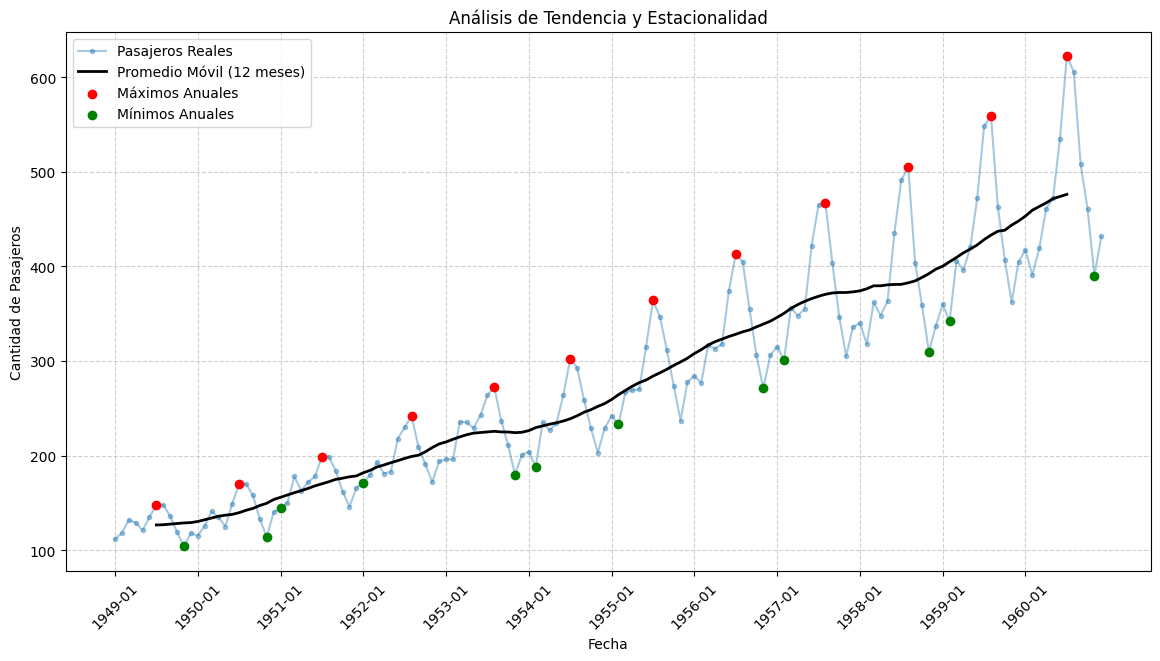

ANÁLISIS DE ESTACIONALIDAD HISTÓRICA
Meses de mayor demanda (Picos):
  * Julio: fue el pico máximo en 7 años.
  * Agosto: fue el pico máximo en 5 años.

Meses de menor demanda (Valles):
  * Noviembre: fue el punto más bajo en 6 años.
  * Febrero: fue el punto más bajo en 4 años.
  * Enero: fue el punto más bajo en 2 años.


In [23]:
# Calcular el promedio móvil de 12 meses (ventana de un año completo)
# window=12: suma los 12 meses alrededor de cada mes
# center=True: coloca el promedio en el mes central para que no se desfase
# Resultado: identifica la tendencia suavizando las variaciones mensuales
df['Promedio_Movil'] = df['Passengers'].rolling(window=12, center=True).mean()

# Identificar los máximos y mínimos anuales
# Extraer el año de cada fecha para agrupar los datos por año
df['Year'] = df['Month'].str[:4]
max_per_year = df.loc[df.groupby('Year')['Passengers'].idxmax()]
min_per_year = df.loc[df.groupby('Year')['Passengers'].idxmin()]

# Visualizar la serie original, la tendencia suavizada y los puntos extremos
plt.figure(figsize=(14, 7))
plt.plot(df['Month'], df['Passengers'], label='Pasajeros Reales', alpha=0.4, color='tab:blue', marker='.')
plt.plot(df['Month'], df['Promedio_Movil'], label='Promedio Móvil (12 meses)', color='black', linewidth=2)

# Destacar con puntos rojos y verdes los máximos y mínimos de cada año
plt.scatter(max_per_year['Month'], max_per_year['Passengers'], color='red', label='Máximos Anuales', zorder=5)
plt.scatter(min_per_year['Month'], min_per_year['Passengers'], color='green', label='Mínimos Anuales', zorder=5)

plt.title('Análisis de Tendencia y Estacionalidad')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks(df['Month'][::12], rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Mostrar el resumen del análisis de estacionalidad
# Tabla de equivalencia entre números de mes y nombres
nombres_meses = {
    '01': 'Enero', '02': 'Febrero', '03': 'Marzo', '04': 'Abril',
    '05': 'Mayo', '06': 'Junio', '07': 'Julio', '08': 'Agosto',
    '09': 'Septiembre', '10': 'Octubre', '11': 'Noviembre', '12': 'Diciembre'
}

print("ANÁLISIS DE ESTACIONALIDAD HISTÓRICA")

# Contar cuántas veces cada mes fue el máximo anual
print("Meses de mayor demanda (Picos):")
max_counts = max_per_year['Month'].str[5:].value_counts()
for mes_num, cant in max_counts.items():
    print(f"  * {nombres_meses[mes_num]}: fue el pico máximo en {cant} años.")

# Contar cuántas veces cada mes fue el mínimo anual
print("\nMeses de menor demanda (Valles):")
min_counts = min_per_year['Month'].str[5:].value_counts()
for mes_num, cant in min_counts.items():
    print(f"  * {nombres_meses[mes_num]}: fue el punto más bajo en {cant} años.")


Como se puede observar en el gráfico, se aprecia una clara tendencia creciente en la cantidad de pasajeros a lo largo de los 12 años analizados.

Por otro lado, a partir del análisis de los meses con mayor y menor cantidad de pasajeros, se puede inferir que estos datos probablemente corresponden a un país del hemisferio norte (posiblemente Estados Unidos). Durante los meses de verano (junio, julio y agosto) se registran un mayor número de viajes en avión, lo que podría explicarse por el período de vacaciones. En cambio, durante el invierno la demanda disminuye, con una caída particularmente marcada en noviembre. Esto podría deberse a que muchas personas evitan viajar en ese mes mientras se preparan para las fiestas de fin de año; posteriormente, en diciembre, la demanda vuelve a incrementarse levemente debido a celebraciones como Navidad y al inicio del período vacacional. Además, es razonable suponer que, en los meses más fríos, en general disminuye la disposición de las personas a viajar.

### Punto 3

Para el punto 3 del Ítem A, el objetivo es transformar la serie de tiempo (una sola columna de datos) en una matriz de entrenamiento que el modelo de regresión lineal pueda entender.

Primero hay que tener en cuenta que la serie de datos tiene un comportamiento estacional de 12 meses. Es decir, lo que ocurre en un mes muchas veces está relacionado con lo que ocurrió durante el año anterior. Por esta razón, no conviene tratar cada dato como si fuera completamente independiente de los demás.

Para poder entrenar un modelo de predicción, es necesario transformar esta serie temporal (que es simplemente una lista de valores a lo largo del tiempo) en un conjunto de datos que el modelo pueda utilizar para aprender. Para lograrlo se utiliza una técnica llamada ventana deslizante (*sliding window*).

La idea es bastante simple. En lugar de mirar un solo mes, se toman 12 meses consecutivos y se usan como información de entrada. Esos 12 meses funcionan como “pistas” que le permiten al modelo entender cómo viene evolucionando la serie. Luego, el mes siguiente (el número 13) se utiliza como el valor que el modelo debe intentar predecir.

Por ejemplo, el modelo observa los datos desde enero hasta diciembre de un año y, con esa información, intenta predecir cuántos pasajeros habrá en enero del año siguiente.

Una vez hecho esto, la ventana se mueve un mes hacia adelante y se repite el proceso. Ahora el modelo toma los datos desde febrero hasta enero del año siguiente, e intenta predecir el valor de febrero. Este procedimiento continúa avanzando mes a mes a lo largo de toda la serie.

De esta manera se generan muchas muestras de entrenamiento a partir de una única serie histórica. En cada nueva muestra, la mayoría de los meses se repiten (porque la ventana solo se mueve un mes), pero el objetivo a predecir cambia. Esto permite construir un conjunto de datos mucho más grande y útil para entrenar el modelo.

In [24]:
# Preparar los datos para entrenar el modelo (sliding window)

# Extraer los valores de pasajeros como una lista sin estructura de tabla
serie = df['Passengers'].values

X = []
y = []
ventana = 12  # Tamaño de la ventana: usar 12 meses para predecir el siguiente

# Crear muestras deslizando la ventana sobre la serie
for i in range(len(serie) - ventana):
    # Entrada: 12 meses consecutivos (desde i hasta i+11)
    X.append(serie[i : i + ventana])
    # Salida: el mes siguiente (posición i+12)
    y.append(serie[i + ventana])

# Convertir de listas de Python a arrays de NumPy (formato que usa el modelo)
X = np.array(X)
y = np.array(y)

# Verificar las dimensiones obtenidas
print(f"Dimensiones de la matriz de entrada (X): {X.shape}")  # Matriz: 132 muestras × 12 características
print(f"Dimensiones del vector de salida (y): {y.shape}")     # Vector: 132 valores objetivo

# Mostrar un ejemplo de la primera muestra
print("\nEjemplo de la primera muestra de entrenamiento:")
print(f"X[0] (Meses 1 al 12): {X[0]}")
print(f"y[0] (Mes 13): {y[0]}")


Dimensiones de la matriz de entrada (X): (132, 12)
Dimensiones del vector de salida (y): (132,)

Ejemplo de la primera muestra de entrenamiento:
X[0] (Meses 1 al 12): [112 118 132 129 121 135 148 148 136 119 104 118]
y[0] (Mes 13): 115


## Item B


### Punto 1



En este punto se implementa el modelo que se va a usar para predecir la serie temporal a partir de los datos construidos en el punto anterior.  

El objetivo general es encontrar una función $\phi(X)$ que permita estimar una salida $Y$ a partir de una entrada $X$:

$$
\hat Y = \phi(X)
$$

En teoría, el regresor óptimo en el sentido de error cuadrático medio es la esperanza condicional:

$$
\phi(X) = \mathbb{E}[Y \mid X=x]
$$

Como esa función no es conocida, se la aproxima con un modelo lineal.

En este problema, para cada instante $t$ se toman como entrada los 12 meses anteriores y como salida el valor del mes actual:

$$
X_t = [y_{t-12}, y_{t-11}, \dots, y_{t-1}],
\qquad
Y_t = y_t
$$

De esta forma, el predictor propuesto es:

$$
\hat y_t = b + \sum_{k=1}^{12} w_k\, y_{t-k}
$$

Donde $b$ y los coeficientes $w_k$ son parámetros desconocidos que se estiman a partir de los datos.

Es importante notar que no se busca un conjunto distinto de pesos para cada mes, sino un único conjunto global de parámetros que funcione lo mejor posible para todas las muestras de entrenamiento.

Para eso, los parámetros se obtienen minimizando el error cuadrático total:

$$
\min_{b,w}\sum_t (\hat y_t - y_t)^2
$$

En otras palabras: se quiere predecir el próximo valor como una combinación lineal de los últimos 12 valores, aprendiendo a partir de los datos cuánto pesa cada uno.

En forma matricial, si se agrega una columna de unos a la matriz de datos, la solución de mínimos cuadrados es:

$$
\theta = ( X^T ⋅ X)^{-1} X^T y
$$

Donde $\theta = [b, w_1, \dots, w_{12}]^T$.





In [25]:
class LinearRegression:
    def __init__(self):
        # Almacenar los parámetros aprendidos (b y w1, w2, ..., w12)
        self.params_ = None

    def fit(self, X, y):
        """
        Entrenar el modelo usando la solución directa de mínimos cuadrados.
        Se calcula la recta (o hiperplano) que mejor ajusta los datos.
        """
        # Añadir una columna de unos a X para capturar el término independiente (b), el bias u ordenada al origen.
        # Esto permite representar y = b + w1*x1 + w2*x2 + ... de forma matricial
        X_aug = np.c_[np.ones(X.shape[0]), X]

        # Aplicar la fórmula de mínimos cuadrados: (X^T * X)^(-1) * X^T * y
        # @ representa multiplicación matricial, .T da la transpuesta
        self.params_ = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y

    def predict(self, X):
        """
        Generar predicciones para nuevos datos usando el modelo entrenado.
        Toma 12 valores de entrada y retorna el valor predicho.
        """
        # Aumentar la matriz con una columna de unos para mantener consistencia
        X_aug = np.c_[np.ones(X.shape[0]), X]
        # Multiplicar X aumentada por los parámetros aprendidos
        return X_aug @ self.params_

    def mean_squared_error(self, X, y):
        """
        Calcular cuántos pasajeros erró el modelo en promedio (en términos al cuadrado).
        Valores más bajos indican mejor desempeño.
        """
        y_pred = self.predict(X)
        # Error cuadrático medio: promedio de (lo que pasó - lo que se predijo)²
        error = np.mean((y - y_pred) ** 2)
        return error


### Punto 2


Una vez creada esta clase, se la entrena con los datos del ítem A.

In [26]:
# Crear una instancia del modelo
modelo_matricial = LinearRegression()

# Entrenar el modelo con los datos preparados en el punto A.3
modelo_matricial.fit(X, y)

# Extraer los parámetros aprendidos
pesos = modelo_matricial.params_

# Mostrar el término independiente y los pesos de cada mes
print(f"Término independiente (b): {pesos[0]:.4f}")
print(f"Pesos asociados a cada mes: \n{pesos[1:]}")

Término independiente (b): 9.4369
Pesos asociados a cada mes: 
[ 0.61268285  0.31794891 -0.25287341  0.27933163 -0.26873158  0.1790373
 -0.19835968  0.23357866 -0.21532935  0.19438396 -0.27158819  0.44370462]


A continuación se presenta el gráfico para comparar la predicción con la serie original.

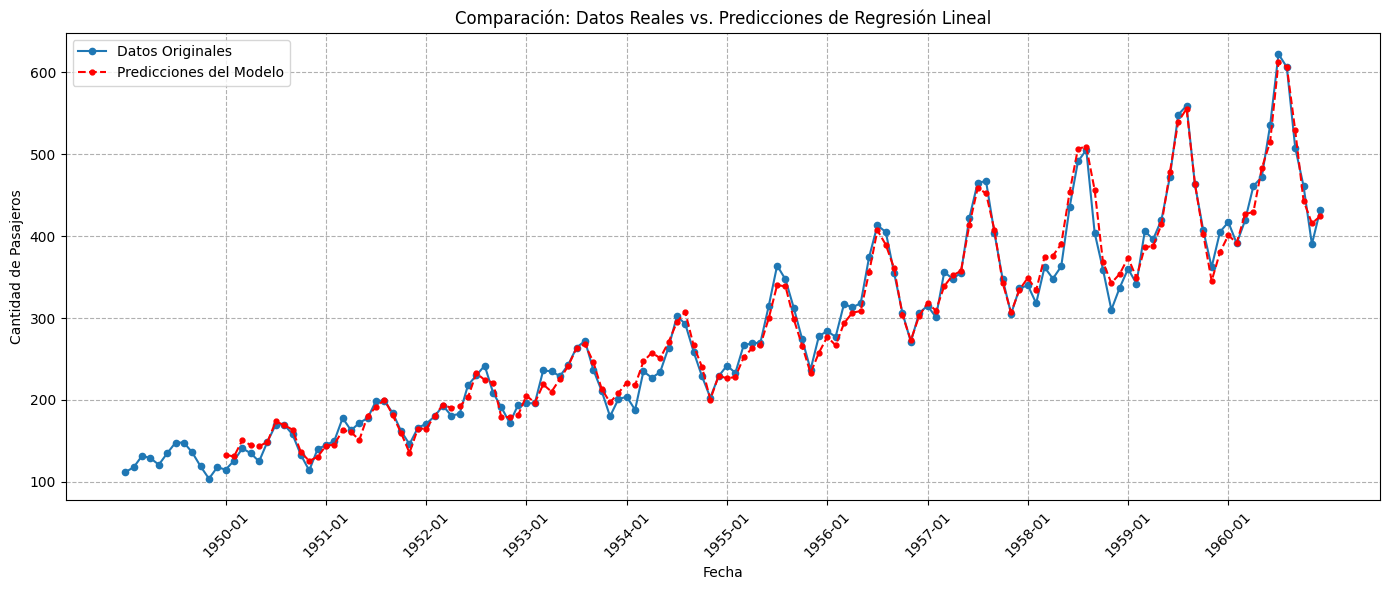

Error Cuadrático Medio (MSE): 182.5376
Raíz del Error Cuadrático Medio (RMSE): 13.5106


In [27]:
# Obtener predicciones del modelo para todos los datos de entrenamiento
y_pred = modelo_matricial.predict(X)

# Crear visualización comparativa
plt.figure(figsize=(14, 6))

# Graficar la serie real
plt.plot(df['Month'], df['Passengers'], label='Datos Originales', marker='.', markersize = 9)

# Graficar las predicciones del modelo en rojo (comienza en el mes 13)
plt.plot(df['Month'][12:], y_pred, label='Predicciones del Modelo', color='red', linestyle='--', marker='.', markersize = 7)

plt.title('Comparación: Datos Reales vs. Predicciones de Regresión Lineal')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks(df['Month'][12::12], rotation=45)  # Marcar cada año en el eje X
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# Calcular y mostrar métricas finales
mse_final = modelo_matricial.mean_squared_error(X, y)
rmse_final = np.sqrt(mse_final)
print(f"Error Cuadrático Medio (MSE): {mse_final:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_final:.4f}")


Del gráfico se observa que la predicción comienza un año después del inicio de la serie. Esto tiene sentido, ya que para estimar un mes el modelo necesita disponer de los 12 meses anteriores. Por eso, el primer mes que puede predecirse es enero de 1950, usando como entrada los datos de 1949, que es justamente lo que se ve en el gráfico.

Por otro lado, analizando el error cuadrático medio, dado que el MSE está expresado en pasajeros al cuadrado, su interpretación directa no resulta tan intuitiva. Por eso es más útil considerar el RMSE (Root Mean Squared Error), es decir, la raíz del error cuadrático medio, que vuelve a expresar el error en la misma unidad que la variable original (en este caso, cantidad de pasajeros, ya que es lo que se está intentando estimar cada mes).

En este caso, el RMSE es alrededor de 13.5 pasajeros, es decir, del orden de 14, lo que indica que el error típico de predicción mensual es aproximadamente de ese valor. En los primeros años de la serie, donde la cantidad de pasajeros es menor, ese error representa una fracción más relevante del valor real (prácticamente el 10%) que en los últimos años, ya que a medida que la serie crece, el mismo error absoluto pasa a representar un porcentaje menor.

### Punto 3

En esta sección se busca estimar los próximos 30 meses con el algoritmo de regresión lineal.

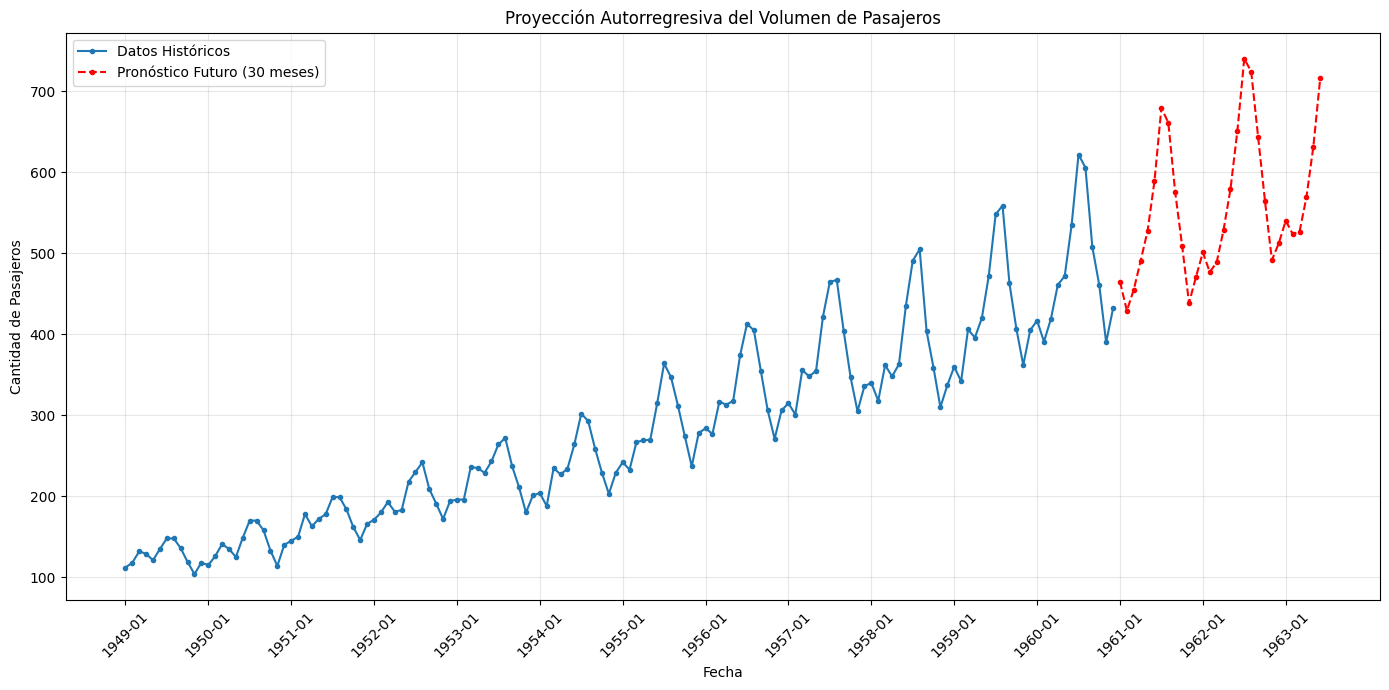

In [28]:
# Preparar la ventana inicial con los últimos 12 meses reales
ultima_ventana = serie[-12:].reshape(1, -1)
predicciones_futuras = []

# Generar predicciones de forma iterativa (autorregresiva) para 30 meses futuros
for i in range(30):
    # Usar la ventana actual para predecir el siguiente mes
    pred_mes = modelo_matricial.predict(ultima_ventana)

    # Guardar la predicción (pred_mes devuelve un array, se extrae el valor con [0])
    predicciones_futuras.append(pred_mes[0])

    # Deslizar la ventana: eliminar el mes más antiguo e insertar la nueva predicción
    # Esto simula el avance del tiempo mes a mes
    nueva_ventana = np.append(ultima_ventana[0, 1:], pred_mes)
    ultima_ventana = nueva_ventana.reshape(1, -1)

# Visualizar la serie histórica y el pronóstico futuro
plt.figure(figsize=(14, 7))

# Graficar el historial de datos reales
meses_originales = np.arange(len(serie))
plt.plot(meses_originales, serie, label='Datos Históricos', color='tab:blue', marker='.')

# Graficar las predicciones futuras (comienzan donde termina el historial)
meses_futuros = np.arange(len(serie), len(serie) + 30)
plt.plot(meses_futuros, predicciones_futuras, label='Pronóstico Futuro (30 meses)',
         color='red', linestyle='--', marker='.')

# Crear etiquetas de fecha para el eje X
# Usar los meses históricos del dataframe
meses_historicos = df['Month'].values

# Generar etiquetas para los meses futuros (continuando el patrón)
# El último año en los datos es 1960, continuamos desde 1961
ultimo_mes = df['Month'].iloc[-1]  # '1960-12'
año_inicial_futuro = int(ultimo_mes[:4]) + 1
meses_futuros_labels = []
mes_actual = 1
for i in range(30):
    año = año_inicial_futuro + (mes_actual - 1) // 12
    mes = mes_actual % 12
    if mes == 0:
        mes = 12
        año -= 1
    meses_futuros_labels.append(f'{año}-{mes:02d}')
    mes_actual += 1

# Combinar etiquetas históricas y futuras
todas_las_etiquetas = list(meses_historicos) + meses_futuros_labels

# Mostrar etiquetas cada 12 meses (cada año) para claridad
paso = 12
posiciones_xticks = np.arange(0, len(todas_las_etiquetas), paso)
etiquetas_xticks = [todas_las_etiquetas[i] for i in posiciones_xticks if i < len(todas_las_etiquetas)]

plt.xticks(posiciones_xticks, etiquetas_xticks, rotation=45)

plt.title('Proyección Autorregresiva del Volumen de Pasajeros')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Una vez entrenado el modelo, se lo utiliza para predecir los próximos 30 meses de manera iterativa.
Para obtener la primera predicción se toman los últimos 12 valores reales disponibles de la serie.

Luego, el valor predicho se incorpora a la serie y se utiliza como parte de la entrada para estimar el siguiente mes. Repitiendo este procedimiento se generan los 30 valores futuros.
  
Debe tenerse en cuenta que, a medida que avanza la predicción, los errores pueden acumularse, porque el modelo comienza a alimentarse con sus propias salidas. Por lo que, en general, las primeras predicciones futuras suelen ser más fiables que las más lejanas.

### Punto 4

La base de datos construida en este trabajo no está formada por muestras independientes, ya que cada muestra se obtiene tomando una ventana de 12 meses consecutivos de una misma serie temporal. Por eso, dos muestras vecinas comparten casi toda su información.

En efecto, si:

$$
X_t = [y_{t-12}, y_{t-11}, \dots, y_{t-1}]
$$

Entonces la muestra siguiente es:

$$
X_{t+1} = [y_{t-11}, y_{t-10}, \dots, y_t]
$$

Ambas comparten 11 de sus 12 componentes. Esto muestra que no puede asumirse independencia entre observaciones.

Desde el punto de vista de procesos estocásticos, esto es esperable: en una serie temporal los valores cercanos en el tiempo suelen estar correlacionados. Es decir, el valor de la serie en un instante no es independiente de los valores anteriores. Esa dependencia se describe mediante la autocorrelación, que mide cuánto se parece la serie a sí misma cuando se la desplaza en el tiempo.

Justamente, al construir cada muestra con los últimos 12 valores, se está suponiendo que el valor futuro puede explicarse, al menos en parte, a partir de sus valores pasados. Esta es la idea básica de un modelo autorregresivo (AR): modelar $y_t$ como una combinación lineal de observaciones anteriores. En este caso, el predictor lineal usa como entrada una ventana de 12 retardos, por lo que conceptualmente se parece a un esquema AR de orden 12.

Por lo tanto, no se cumplen estrictamente los supuestos clásicos de muestras i.i.d. (independientes e idénticamente distribuidas). Sin embargo, esto no invalida el enfoque: en problemas de series temporales, la dependencia entre observaciones no es un defecto sino justamente la estructura que se busca explotar para predecir el futuro.

En consecuencia, el modelo sigue siendo útil como predictor lineal, pero la interpretación estadística del error debe hacerse con cuidado, ya que las muestras no provienen de observaciones independientes y existe correlación temporal entre ellas.

## Item C


En este ítem se usa el mismo modelo lineal que en el punto anterior, pero ahora los parámetros no se obtienen directamente: se ajustan paso a paso con gradiente descendente.

La función que mide el error del modelo es:

$$
J(\theta)=\frac{1}{n}\| X ⋅ \theta-y\|^2
$$

Donde ($\theta$) es el vector de parámetros, ($ X$) es la matriz de entrada, ($y$) es el vector de valores reales y ($n$) es la cantidad de datos.

Para minimizar ese error, se calcula su gradiente:

$$
\nabla J(\theta)=\frac{2}{n} X^T(X ⋅\theta-y)
$$

Se actualizan los parámetros con la regla:

$$
\theta^{(t+1)}=\theta^{(t)}-\alpha \nabla J(\theta^{(t)})
$$

Donde ($\alpha$) es el *learning rate*. Además, se busca normalizar las entradas para mejorar la convergencia del algoritmo.

### Punto 1


In [29]:
class LinearRegression:
    def __init__(self):
        """Inicializar el modelo de regresión lineal."""
        # Almacenar los parámetros aprendidos durante el entrenamiento
        self.params_ = None
        # Registrar el error en cada iteración (solo para gradiente descendente)
        self.error_history = []

    def fit(self, X, y):
        """
        Entrenar usando la solución directa de mínimos cuadrados.
        Se obtiene la respuesta exacta calculándola matemáticamente.
        """
        # Añadir columna de unos para el término independiente
        X_aug = np.c_[np.ones(X.shape[0]), X]
        # Aplicar la fórmula: parámetros = (X^T * X)^(-1) * X^T * y
        self.params_ = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y

    def fit_gradient(self, X, y, learning_rate, epochs=10000):
        """
        Entrenar el modelo usando gradiente descendente.
        Ajustar los parámetros paso a paso siguiendo la dirección que reduce el error.
        """
        n_samples, n_features = X.shape
        X_aug = np.c_[np.ones(n_samples), X]

        # Inicializar parámetros en cero (punto de partida)
        self.params_ = np.zeros(X_aug.shape[1])
        self.error_history = []

        for i in range(epochs):
            # Calcular predicciones actuales y cómo se equivocaron
            y_pred = X_aug @ self.params_
            error = y_pred - y

            # Calcular hacia dónde mover los parámetros para reducir el error
            # La fórmula da la dirección de cambio más efectiva (derivada de la función de costo)
            gradient = (2 / n_samples) * (X_aug.T @ error)

            # Ajustar parámetros en la dirección indicada, controlando el tamaño del paso
            self.params_ = self.params_ - learning_rate * gradient

            # Registrar el error actual para seguimiento
            mse = np.mean(error**2)
            self.error_history.append(mse)

            # Detener si el error deja de mejorar significativamente
            if i > 0 and abs(self.error_history[-2] - self.error_history[-1]) < 1e-9:
                print(f"Entrenamiento convergió en iteración: {i}")
                break

    def predict(self, X):
        """
        Usar el modelo entrenado para hacer predicciones en nuevos datos.
        Entrada: matriz con 12 meses de pasajeros.
        Salida: predicción del mes siguiente.
        """
        # Añadir columna de unos para consistencia
        X_aug = np.c_[np.ones(X.shape[0]), X]
        return X_aug @ self.params_

    def mean_squared_error(self, X, y):
        """
        Evaluar qué tan bueno es el modelo midiendo su error promedio.
        Valores menores indican mejor desempeño.
        """
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)


### Punto 2

Una vez redefinida la clase para entrenar el modelo mediante gradiente descendente, se repiten los mismos procedimientos realizados en los puntos 1 y 2 del ítem B.

In [30]:
# Calcular el centro y la escala de cada una de las 12 características
mu_X = np.mean(X, axis=0)      # Centro (promedio) de cada mes
sigma_X = np.std(X, axis=0)    # Amplitud (desviación) de cada mes

# Transformar los datos de entrada: restar el centro y dividir por la amplitud
# Resultado: todos los datos tienen media ~0 y desviación estándar ~1
X_norm = (X - mu_X) / sigma_X

# Mantener los valores objetivo sin cambios (en unidades originales de pasajeros)
y_real = y

print("Características normalizadas a escala uniforme.")


Características normalizadas a escala uniforme.


En esta sección se busca elegir un valor razonable para el learning rate $\alpha$ sin hacerlo completamente a prueba y error.  

La idea es usar la forma matemática de la función de costo para tener una referencia de qué tan grande o qué tan chico conviene que sea el paso del gradiente descendente.

Para regresión lineal, la función de costo es:

$$
J(\theta)=\frac{1}{n}\| X ⋅ \theta-y\|^2
$$

Su curvatura está dada por la Hessiana:

$$
H=\frac{2}{n}X^T⋅  X
$$

A partir de los autovalores de esta matriz se calcula un $\alpha$ teórico conveniente:

$$
\alpha_{\text{opt}}=\frac{2}{\lambda_{\max}+\lambda_{\min}}
$$

Donde $\lambda_{\max}$ es el autovalor más grande de la matriz y $\lambda_{\min}$ el menor. También se busca el límite de estabilidad:

$$
\alpha < \frac{2}{\lambda_{\max}}
$$

La interpretación es sencilla: si $\alpha$ es muy chico, el algoritmo avanza demasiado lento; si es muy grande, puede pasarse del mínimo y no converger.
  
Por eso, en lugar de elegirlo al azar, se usa esta cuenta como guía.

Todo esto se hace sobre los datos normalizados, ya que normalizar mejora la escala de las variables y ayuda a que el descenso por gradiente funcione de manera más estable.

In [31]:
# Preparar datos aumentados con columna de unos
X_aug_norm = np.c_[np.ones(X_norm.shape[0]), X_norm]

# Calcular la matriz Hessiana (matriz de curvatura de la función de costo)
# Define cómo cambia el error en cada dirección de los parámetros
# H = (2/n) * X_aug^T * X_aug
H = (2 / X_aug_norm.shape[0]) * (X_aug_norm.T @ X_aug_norm)

# Encontrar los autovalores de la Hessiana
# Estos indican cómo de "empinada" es la curva en cada dirección
eigenvalues = np.linalg.eigvals(H)
lambda_max = np.max(eigenvalues)  # Mayor cambio de curvatura
lambda_min = np.min(eigenvalues)  # Menor cambio de curvatura

# Calcular el tamaño de paso óptimo
alpha_opt = 2 / (lambda_max + lambda_min)

print(f"Tamaño de paso óptimo calculado: {alpha_opt:.4f}")
print(f"Lambda máximo: {lambda_max}")

Tamaño de paso óptimo calculado: 0.0976
Lambda máximo: 20.491469174678286


Al incluir la columna de unos asociada al sesgo en la matriz aumentada, la Hessiana pasa a construirse sobre todos los parámetros del modelo, incluido el bias. Sin embargo, como las variables de entrada fueron previamente normalizadas y centradas, sus columnas tienen media aproximadamente nula.  

Esto hace que la columna de unos quede casi ortogonal a las demás columnas, por lo que la contribución del bias aparece prácticamente desacoplada del resto de los parámetros. En términos espectrales, esto agrega un autovalor adicional cercano a 2, pero si dicho valor no modifica ni el autovalor máximo ni el mínimo de la Hessiana, entonces el valor de $\alpha_{opt}$ permanece prácticamente igual.

Por eso, aunque es correcto incluir el bias en el cálculo, en este caso particular su incorporación no altera de manera apreciable el learning rate óptimo estimado.

Con el valor de $\alpha$ elegido previamente, se entrena el modelo mediante gradiente descendente durante un número fijo de iteraciones.  

En cada paso, los parámetros se actualizan para intentar reducir el error cuadrático del modelo.

Para analizar si el método está funcionando correctamente, se grafica la evolución de la función de costo a lo largo de las iteraciones.  

Si la curva desciende y luego tiende a estabilizarse, esto indica que el algoritmo está convergiendo. En cambio, si oscila demasiado o crece, puede ser señal de que el learning rate elegido no es adecuado.

Se usa escala logarítmica en el eje vertical para apreciar mejor cómo disminuye el error durante el entrenamiento.

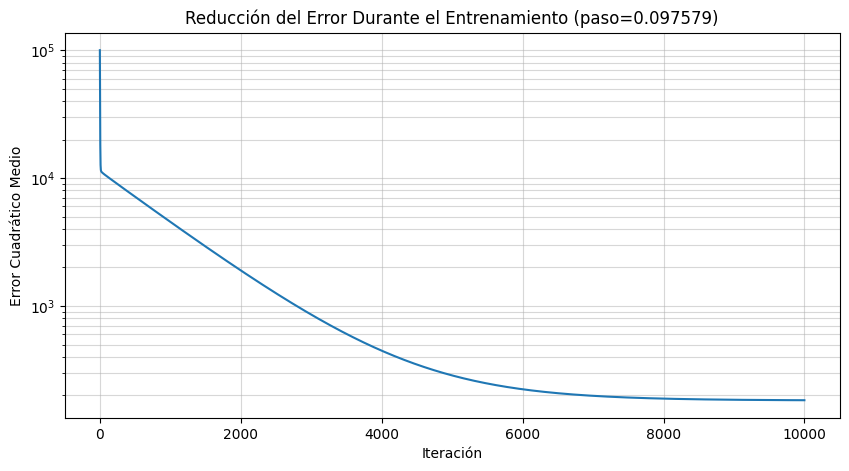

In [32]:
# Usar el tamaño de paso óptimo calculado
alpha = alpha_opt
# alpha = 0.001 # -> de curioso
modelo_gd = LinearRegression()

# Entrenar el modelo mediante gradiente descendente iterativo
# Los parámetros se ajustan gradualmente durante 10,000 iteraciones
modelo_gd.fit_gradient(X_norm, y_real, learning_rate=alpha, epochs=10000)

# Visualizar cómo mejora el error a lo largo del entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(modelo_gd.error_history)
plt.yscale('log')  # Usar escala logarítmica para ver mejor los cambios
plt.title(f'Reducción del Error Durante el Entrenamiento (paso={alpha:.6f})')
plt.xlabel('Iteración')
plt.ylabel('Error Cuadrático Medio')
plt.grid(True, which="both", alpha=0.5)
plt.show()


Del gráfico de la función de costo puede observarse que el error disminuye a medida que avanzan las iteraciones.  

Esto indica que el algoritmo de gradiente descendente está convergiendo correctamente para el valor de learning rate elegido.

La caída inicial es muy pronunciada, lo que muestra que en las primeras iteraciones el modelo corrige rápidamente los parámetros y reduce gran parte del error.  

Luego, la disminución del costo se vuelve más lenta hasta tender a estabilizarse, señal de que el algoritmo se está acercando a una solución de equilibrio.

Además, no se observan oscilaciones fuertes ni divergencia, por lo que el valor de $\alpha$ utilizado resulta adecuado para este problema.

Por otro lado, se eligió un total de 10000 iteraciones para asegurar que el algoritmo tuviera suficiente margen para converger.  

Esta cantidad no surge de una fórmula exacta, sino de un criterio práctico: utilizar un número lo bastante grande y luego verificar mediante la curva de aprendizaje si la función de costo efectivamente se estabiliza.

Del gráfico se observa que, hacia las últimas iteraciones, la disminución del costo ya es muy pequeña, lo que indica que 10000 iteraciones resultan suficientes para este problema.

In [33]:
# Extraer los parámetros aprendidos por gradiente descendente
parametros_gd = modelo_gd.params_
bias_gd = parametros_gd[0]        # Término independiente
pesos_gd = parametros_gd[1:]      # Pesos de las 12 características

# Calcular métricas de desempeño en los datos de entrenamiento
mse_gd = modelo_gd.mean_squared_error(X_norm, y_real)
rmse_gd = np.sqrt(mse_gd)

# Mostrar los resultados del entrenamiento
print(f"Término independiente: {bias_gd:.4f}")
print(f"Pesos de los 12 meses: {pesos_gd[1:]}")
print("-" * 50)
print(f"Error Cuadrático Medio (MSE): {mse_gd:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_gd:.4f}")
print("-" * 50)

# Comparar con el modelo entrenado analíticamente en el punto B
# Verificar que ambos métodos encontraron la misma solución óptima
print(f"Diferencia de MSE entre métodos: {abs(mse_gd - mse_final):.8f}")

Término independiente: 294.2652
Pesos de los 12 meses: [ 33.48750551 -26.68973237  29.37275963 -28.59637858  18.94087506
 -21.51267659  25.96242504 -24.69896651  22.27425189 -31.44698874
  50.94220217]
--------------------------------------------------
Error Cuadrático Medio (MSE): 183.5147
Raíz del Error Cuadrático Medio (RMSE): 13.5468
--------------------------------------------------
Diferencia de MSE entre métodos: 0.97718954


Resulta interesante comparar los parámetros y métricas obtenidas con el método analítico del ítem B y con el entrenamiento por gradiente descendente del ítem C.

Al hacer esta comparación, se observa que los pesos y  el sesgo o bias son distintos entre los dos algoritmos, mientras que el MSE y el RMSE resultan muy similares.

Esto puede entenderse mejor escribiendo el modelo entrenado con variables normalizadas. Si:

$$
x_k'=\frac{x_k-\mu_k}{\sigma_k}
$$

Entonces el predictor aprendido por gradiente descendente puede escribirse como:

$$
\hat y = b' + \sum_{k=1}^{12} w_k' x_k'
$$

Reemplazando la definición de $x_k'$:

$$
\hat y = b' + \sum_{k=1}^{12} w_k' \frac{x_k-\mu_k}{\sigma_k}
$$

Reordenando términos:

$$
\hat y =
\left(
b' - \sum_{k=1}^{12}\frac{w_k'\mu_k}{\sigma_k}
\right)
+ \sum_{k=1}^{12}\frac{w_k'}{\sigma_k}x_k
$$

Por lo tanto, el modelo expresado nuevamente en variables originales tiene coeficientes:

$$
w_k=\frac{w_k'}{\sigma_k}
$$

Y un bias equivalente dado por:

$$
b = b' - \sum_{k=1}^{12}\frac{w_k'\mu_k}{\sigma_k}
$$

Esto muestra que, al normalizar las entradas, tanto los pesos como el sesgo cambian de representación.  
Por eso, una diferencia grande en el bias no implica necesariamente una diferencia real en la capacidad predictiva del modelo, algo que también se ve reflejado en que el MSE y el RMSE de ambos métodos son muy similares.

De hecho, el hecho que estos dos últimos sean muy parecidos, indica que ambos métodos están encontrando soluciones prácticamente equivalentes en términos de ajuste y predicción.

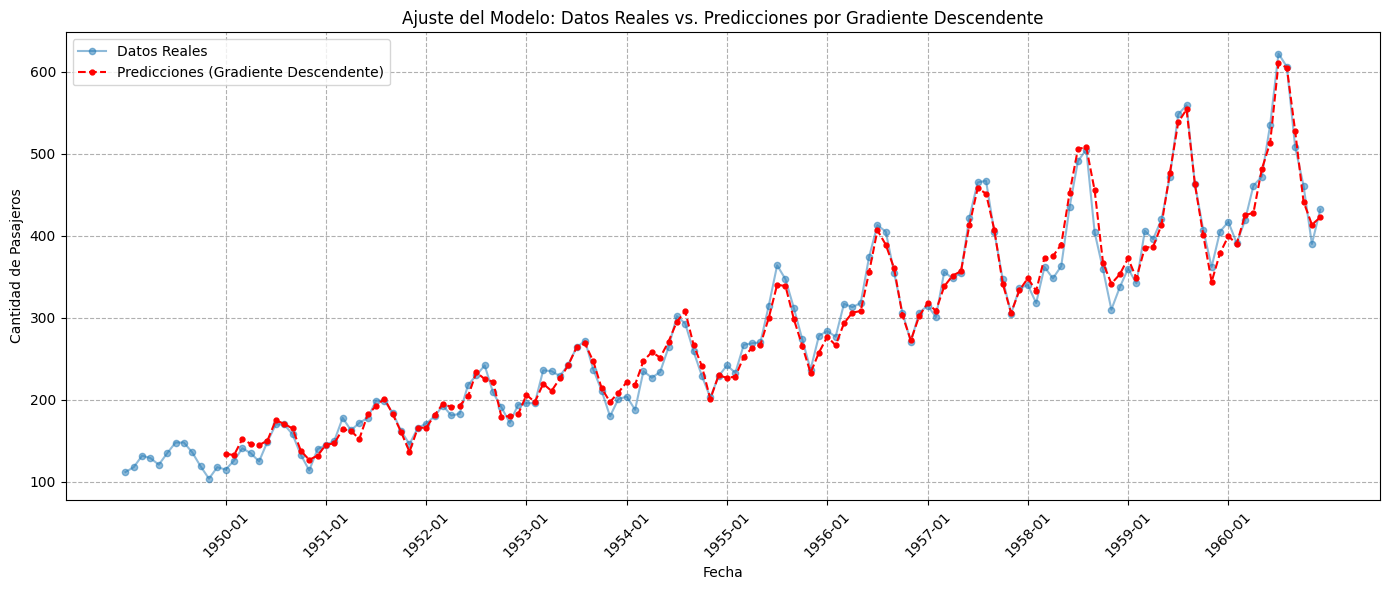

In [34]:
# Generar predicciones del modelo entrenado con gradiente descendente
y_pred_gd = modelo_gd.predict(X_norm)

# Visualizar cómo ajusta el modelo a los datos históricos
plt.figure(figsize=(14, 6))
plt.plot(df['Month'], df['Passengers'], label='Datos Reales', alpha=0.5, marker='.', markersize = 9)
plt.plot(df['Month'][12:], y_pred_gd, label='Predicciones (Gradiente Descendente)', color='red', linestyle='--', marker='.', markersize = 7)
plt.title('Ajuste del Modelo: Datos Reales vs. Predicciones por Gradiente Descendente')

plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks(df['Month'][12::12], rotation=45)  # Marcar cada año
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()


Al comparar el ajuste obtenido mediante gradiente descendente con el obtenido en el ítem B mediante la solución analítica de mínimos cuadrados, se observa que ambas predicciones son prácticamente iguales.

En los dos casos, el modelo logra reproducir razonablemente bien la tendencia creciente y la estacionalidad anual de la serie.  

Las diferencias entre ambas curvas son muy pequeñas, lo cual indica que el gradiente descendente logró converger hacia una solución muy cercana a la obtenida por el método cerrado.

Esto es consistente con la teoría, ya que en ambos casos se está ajustando el mismo predictor lineal; lo único que cambia es la forma de estimar sus parámetros.  

Mientras que en el ítem B la solución se obtiene directamente mediante una expresión matricial, en este punto se llega a un resultado equivalente a través de un proceso iterativo.

Por último, se realiza la predicción de los próximos 30 meses.

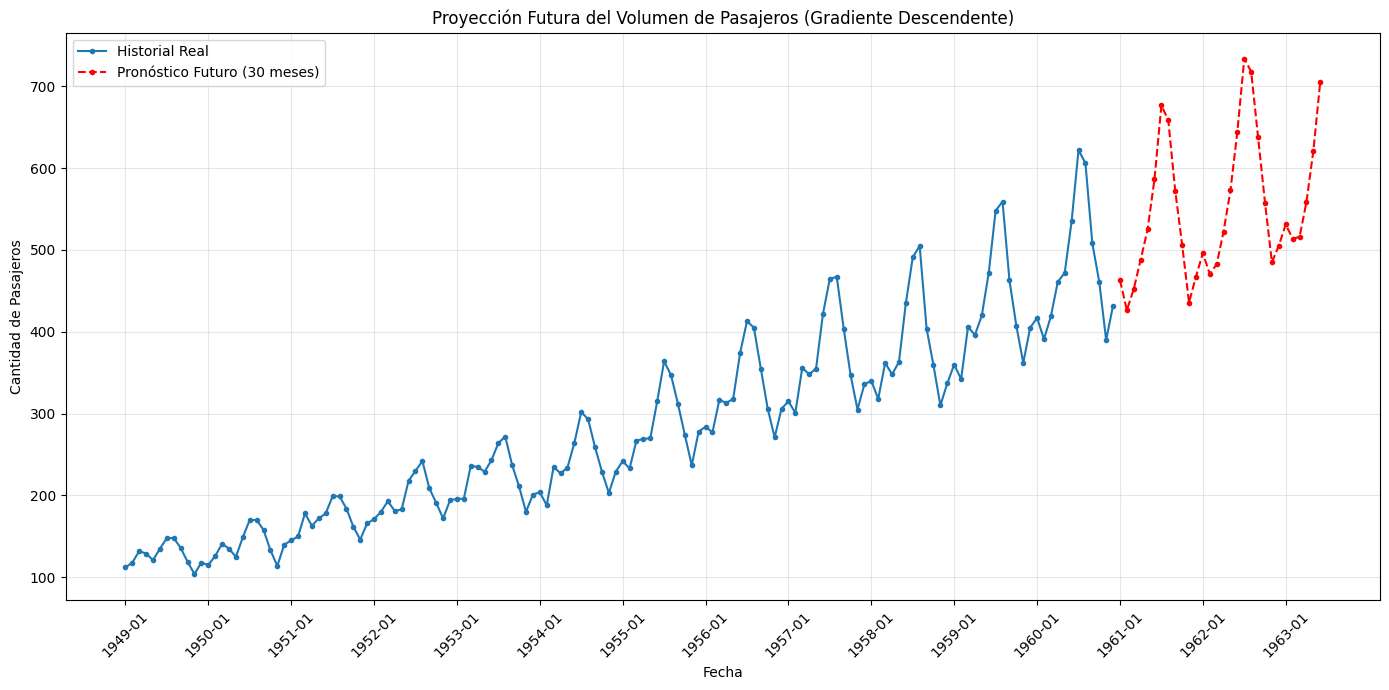

In [35]:
# Preparar el contexto inicial: los últimos 12 meses del historial
ventana_actual = serie[-12:]
predicciones_futuras_gd = []

# Generar predicciones autorregresivas para 30 meses futuros
for _ in range(30):
    # Convertir los datos al mismo formato usado durante el entrenamiento
    # (normalizar usando media y desviación estándar calculadas previamente)
    ventana_norm = (ventana_actual - mu_X) / sigma_X
    ventana_norm = ventana_norm.reshape(1, -1)

    # Usar el modelo para predecir el siguiente mes
    # El resultado automáticamente está en la escala de pasajeros (sin normalizar)
    pred = modelo_gd.predict(ventana_norm)[0]
    predicciones_futuras_gd.append(pred)

    # Actualizar la ventana: eliminar el primer mes e insertar la predicción nueva
    # Esto simula el avance del tiempo y prepara para la siguiente predicción
    ventana_actual = np.append(ventana_actual[1:], pred)

# Visualizar la proyección futura con etiquetas de fecha
plt.figure(figsize=(14, 7))

# Graficar el historial de datos reales
meses_originales = np.arange(len(serie))
plt.plot(meses_originales, serie, label='Historial Real', color='tab:blue', marker='.')

# Graficar las predicciones futuras
meses_futuros = np.arange(len(serie), len(serie) + 30)
plt.plot(meses_futuros, predicciones_futuras_gd, color='red', linestyle='--', marker='.',
         label='Pronóstico Futuro (30 meses)')

# Crear etiquetas de fecha para el eje X
# Usar los meses históricos del dataframe
meses_historicos = df['Month'].values

# Generar etiquetas para los meses futuros
ultimo_mes = df['Month'].iloc[-1]  # '1960-12'
año_inicial_futuro = int(ultimo_mes[:4]) + 1
meses_futuros_labels = []
mes_actual = 1
for i in range(30):
    año = año_inicial_futuro + (mes_actual - 1) // 12
    mes = mes_actual % 12
    if mes == 0:
        mes = 12
        año -= 1
    meses_futuros_labels.append(f'{año}-{mes:02d}')
    mes_actual += 1

# Combinar etiquetas históricas y futuras
todas_las_etiquetas = list(meses_historicos) + meses_futuros_labels

# Mostrar etiquetas cada 12 meses para claridad
paso = 12
posiciones_xticks = np.arange(0, len(todas_las_etiquetas), paso)
etiquetas_xticks = [todas_las_etiquetas[i] for i in posiciones_xticks if i < len(todas_las_etiquetas)]

plt.xticks(posiciones_xticks, etiquetas_xticks, rotation=45)

plt.title('Proyección Futura del Volumen de Pasajeros (Gradiente Descendente)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El pronóstico a 30 meses obtenido con gradiente descendente mantiene la forma general de la serie histórica: se observa una tendencia creciente junto con oscilaciones periódicas que reflejan la estacionalidad anual.

Como la predicción se realiza de manera autorregresiva, cada valor nuevo estimado pasa a formar parte de la entrada del paso siguiente.  

Esto permite extender la serie, pero también implica que los errores pueden acumularse a medida que se avanza en el tiempo.

Comparando este resultado con el del ítem B, se ve que la proyección futura es muy parecida.  

Esto refuerza la idea de que ambos métodos están ajustando esencialmente el mismo modelo, aunque por procedimientos distintos.